# HS-Array D28 — Nuclear Segmentation Walkthrough

**Dataset:** WARD00034-R2 (`5c6bf125`), D28 AB Rep1, 192 wells × 9 fields × 10 z-planes  
**Channel:** DAPI (ch01), 0.2967 µm/px, z-spacing 1.997 µm  
**Goal:** Walk every step of `1_nucleus_segmentation.py` on real data — raw TIFFs → MIP → each segmentation intermediate → final labelled masks with crops.

## Pipeline overview

```
10 z-planes (DAPI, ch01)
    │
    ▼  max-project → MIP (detection only; intensity measured on best-focus plane)
  MIP (2160×2160, uint16)
    │
    ▼  Gaussian-fit contrast stretch  [µ−1σ … µ+7σ  →  0…1]
  image_norm (float32)
    │
    ▼  Gaussian blur  [σ=1]
  blurred (float32)
    │
    ▼  Step 1 low-level threshold  [(triangle + p50) / 2]
    │  → remove_small_objects (min 3500 px²) → dilation (disk 2)
  img_low_level (bool)
    │
    ▼  Step 2 per-object Otsu refinement  [global floor = 0.333×Otsu]
    │  → for each low-level blob: local_otsu; threshold at 0.98×local_otsu
  img_high_level (bool)
    │
    ▼  binary_fill_holes → dilation (disk 2)
    │  → remove_small_objects (min 3500 px²) → label
  nuc_seg (int32 label image)
```

**Note on PX_UM:** This dataset uses **0.2967 µm/px** (from `index.xml`).  
Do NOT use the Panel_1 value of 0.094187 µm/px — it would give areas ~10× too small.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import tifffile
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from scipy import ndimage as ndi
from scipy.stats import norm
from skimage import filters, morphology
from skimage.measure import label as sklabel, regionprops_table
from skimage.segmentation import find_boundaries
from skimage.color import label2rgb

matplotlib.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 8, 'axes.labelsize': 8})

# ── paths ─────────────────────────────────────────────────────────────────────
REPO     = Path('/Users/pmihack/claire/hs-array')
UUID     = '5c6bf125-6e0f-41be-a447-b03ff294c9cc'
IMG_DIR  = REPO / 'data/D28_AB_Rep1' / UUID / 'images'
# nuclei_features now live under the run-ID system: outputs/run_<id>/nuclei_features/
PARQUET  = sorted((REPO / 'outputs').glob(f'run_*/nuclei_features/{UUID[:8]}*nuclei_features*.parquet'))[0]
OUT_DIR  = REPO / 'outputs/qc_figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── constants (from 1_nucleus_segmentation.py) ─────────────────────────────────
PX_UM    = 0.2967          # µm/px from index.xml — NOT the Panel_1 0.094187
Z_UM     = 1.997           # µm/plane
N_PLANES = 10

INTENSITY_SCALING_PARAM = [1, 7]   # [low_sigma, high_sigma] for contrast stretch
BLUR_SIGMA = 1
MIN_AREA   = 3500          # px²  ≈ 308 µm²  (minimum nuclear area)

print(f'Parquet: {PARQUET.name}')
print(f'Image dir exists: {IMG_DIR.exists()}')
print(f'Pixel size: {PX_UM} µm/px  |  MIN_AREA {MIN_AREA} px² = {MIN_AREA*PX_UM**2:.1f} µm²')

## 1. Load segmentation results & pick a walkthrough site

We pick a **frame-5** (center field in the 3×3 per-well grid), **high-density** (≥10 nuclei), **high-yield well** (≥65 total nuclei). This avoids two real artifacts in this dataset:

- **Well-edge ring artifact:** Opera Phenix fields at the well periphery (frames 1,2,3,7,9 especially) can show the bright circular well boundary in the DAPI channel. This ring dominates the Gaussian-fit contrast stretch, producing anomalously high σ, and then fails the per-object Otsu step (hollow structure). The algorithm handles it correctly — it discards the ring — but it makes a poor tutorial site.
- **Sparse-well bias:** Very low-yield wells (<20 nuclei/well) have imaging or seeding issues unrelated to the algorithm.

In [2]:
df = pd.read_parquet(PARQUET)
df['area_um2'] = df['area'] * PX_UM**2

print(f"Total nuclei: {len(df):,}")
print(f"Wells: {df[['Row','Column']].drop_duplicates().shape[0]}  "
      f"(median {df.groupby(['Row','Column']).size().median():.0f} nuclei/well)")
print(f"Sites: {df[['Row','Column','Frame']].drop_duplicates().shape[0]}  "
      f"(median {df.groupby(['Row','Column','Frame']).size().median():.1f} nuclei/site)")

site_counts = df.groupby(['Row','Column','Frame']).size().reset_index(name='n')

# Pick walkthrough site that avoids the well-edge ring artifact:
#   - Frame 5 = center field in the 3×3 per-well grid (frame 5 of 9)
#     avoids the visible well-edge boundary that appears in edge frames.
#   - ≥10 nuclei/site for a dense, instructive illustration
#   - Central plate region (rows 5–12, cols 5–18) — avoids plate-edge wells
#   - Well must have ≥65 total nuclei (high-yield wells have clean seeding)
well_totals = df.groupby(['Row','Column']).size().reset_index(name='well_n')
cand = (site_counts
        .merge(well_totals, on=['Row','Column'])
        .query("Frame == 5 and n >= 10 and well_n >= 65"
               " and Row >= 5 and Row <= 12 and Column >= 5 and Column <= 18")
        .sort_values('n', ascending=False))

if cand.empty:
    # fallback: relax frame constraint, keep density + well-quality filters
    cand = (site_counts
            .merge(well_totals, on=['Row','Column'])
            .query("n >= 10 and well_n >= 65"
                   " and Row >= 5 and Row <= 12 and Column >= 5 and Column <= 18")
            .sort_values('n', ascending=False))

row0 = cand.iloc[0]
WT_ROW, WT_COL, WT_FRAME = int(row0.Row), int(row0.Column), int(row0.Frame)

print(f"\nWalkthrough site: r{WT_ROW:02d}c{WT_COL:02d} frame={WT_FRAME}"
      f"  ({row0.n} nuclei/site, {row0.well_n} nuclei/well)"
      f"  [frame 5 = center field, avoids well-edge ring]")

Total nuclei: 10,198
Wells: 192  (median 55 nuclei/well)
Sites: 1634  (median 6.0 nuclei/site)

Walkthrough site: r09c16 frame=5  (20 nuclei/site, 77 nuclei/well)  [frame 5 = center field, avoids well-edge ring]


## 2. The z-stack: all 10 planes

Data is widefield, 10 planes × 1.997 µm = ~20 µm depth. Each plane is a separate TIFF (`p01`–`p10`, `ch01t01`).  
Nuclei at different z-positions come in and out of focus — hence the MIP for detection.  
**We also identify the best-focus plane** (max variance-of-Laplacian) — this is the plane used for intensity quantification in Step 3 (TDP-43 localization).

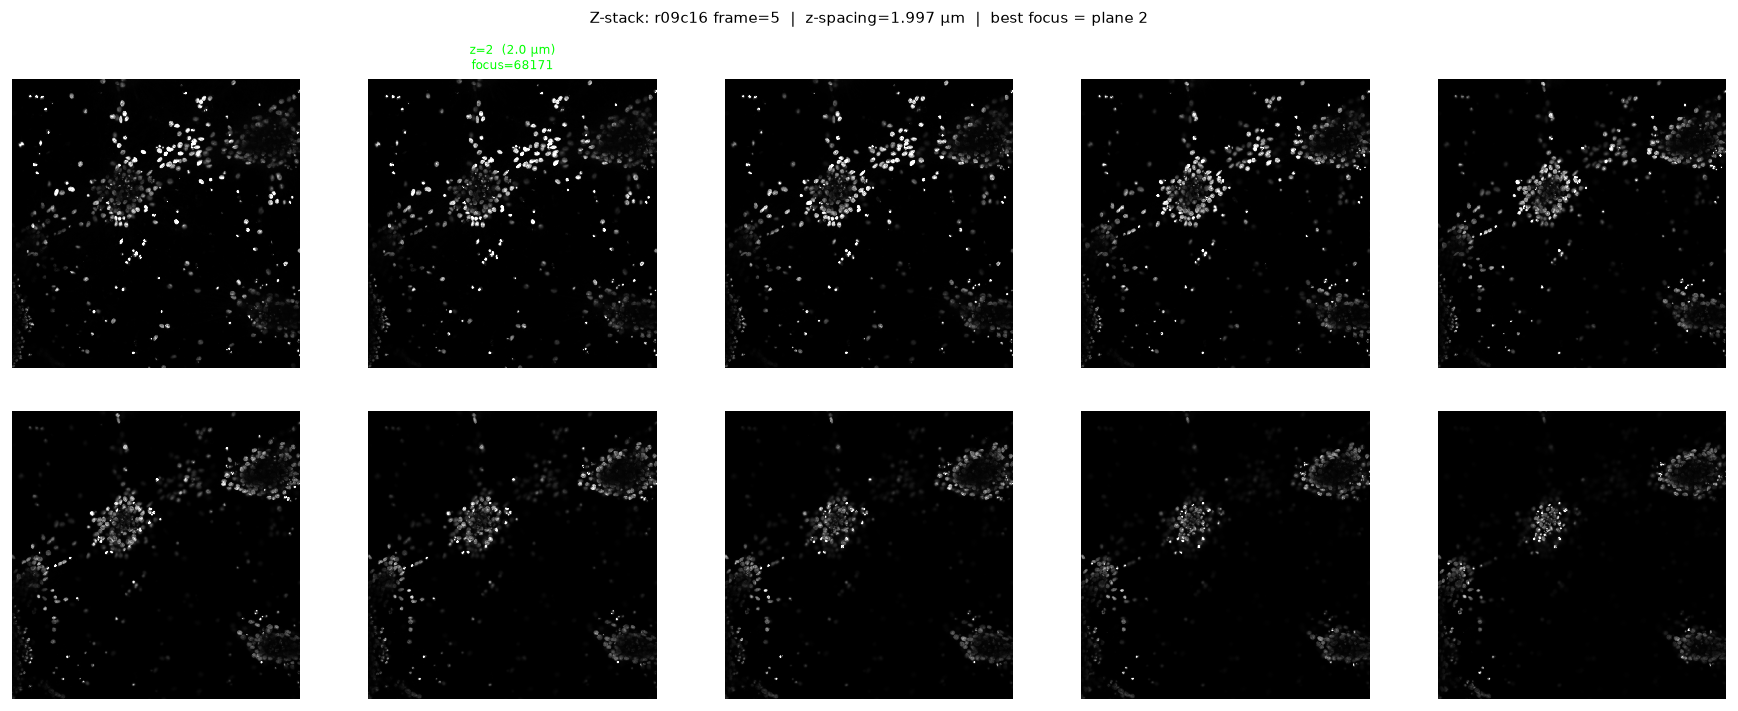

Best focus: plane 2 of 10  (z = 2.0 µm)


In [3]:
def get_plane_paths(row, col, frame, n_planes=N_PLANES):
    subdir = IMG_DIR / f'r{row:02d}c{col:02d}'
    return [subdir / f'r{row:02d}c{col:02d}f{frame:02d}p{p:02d}-ch01t01.tiff'
            for p in range(1, n_planes + 1)]

plane_paths = get_plane_paths(WT_ROW, WT_COL, WT_FRAME)
planes = [tifffile.imread(p).astype(np.float32) for p in plane_paths]

# Best-focus: max variance of Laplacian (same metric as 3_tdp43_localization.py)
from skimage.filters import laplace
focus_scores = [np.var(laplace(p)) for p in planes]
best_z = int(np.argmax(focus_scores))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle(f'Z-stack: r{WT_ROW:02d}c{WT_COL:02d} frame={WT_FRAME}  |  '
             f'z-spacing={Z_UM} µm  |  best focus = plane {best_z+1}', fontsize=9)

vmin = np.percentile(planes[best_z], 1)
vmax = np.percentile(planes[best_z], 99.5)

for i, (ax, plane) in enumerate(zip(axes.flat, planes)):
    z_um = i * Z_UM
    ax.imshow(plane, cmap='gray', vmin=vmin, vmax=vmax, interpolation='none')
    label_str = f'z={i+1}  ({z_um:.1f} µm)\nfocus={focus_scores[i]:.0f}'
    color = 'lime' if i == best_z else 'white'
    ax.set_title(label_str, fontsize=7, color=color)
    ax.axis('off')
    if i == best_z:
        for spine in ax.spines.values():
            spine.set_edgecolor('lime'); spine.set_linewidth(2)

plt.tight_layout()
plt.savefig(OUT_DIR / 'zstack_all_planes.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Best focus: plane {best_z+1} of {N_PLANES}  (z = {best_z*Z_UM:.1f} µm)')

## 3. MIP construction

Maximum-intensity projection collapses each pixel to its brightest value across all z-planes.  
This ensures every nucleus — regardless of which z-plane it peaks at — contributes a strong signal to the 2D segmentation.

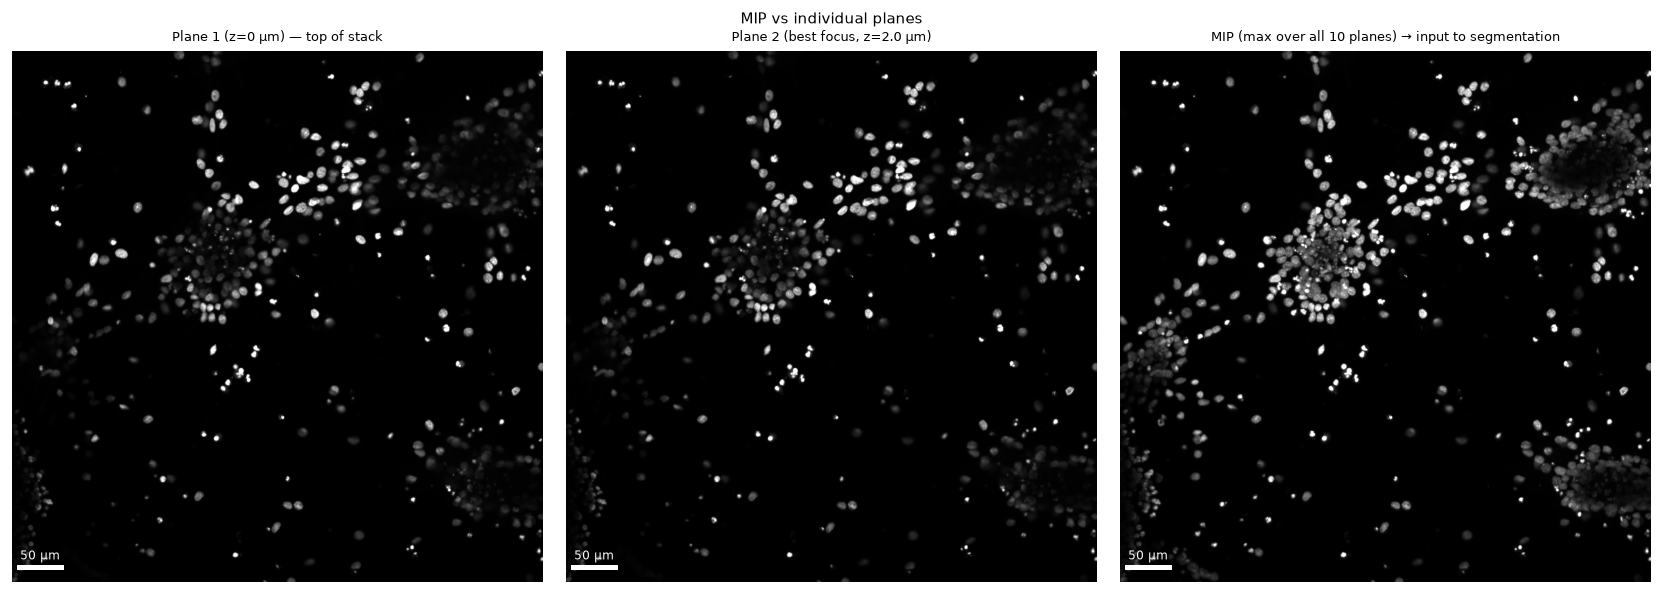

In [4]:
mip = np.max(np.stack(planes), axis=0)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('MIP vs individual planes', fontsize=9)

vmin, vmax = np.percentile(mip, [1, 99.5])

axes[0].imshow(planes[0], cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title('Plane 1 (z=0 µm) — top of stack'); axes[0].axis('off')

axes[1].imshow(planes[best_z], cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title(f'Plane {best_z+1} (best focus, z={best_z*Z_UM:.1f} µm)'); axes[1].axis('off')

axes[2].imshow(mip, cmap='gray', vmin=vmin, vmax=vmax)
axes[2].set_title('MIP (max over all 10 planes) → input to segmentation'); axes[2].axis('off')

# Scalebar: 50 µm
sb_px = int(50 / PX_UM)
for ax in axes:
    ax.plot([30, 30+sb_px], [2100, 2100], 'w-', lw=3)
    ax.text(30 + sb_px//2, 2080, '50 µm', color='white', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(OUT_DIR / 'mip_vs_planes.png', dpi=130, bbox_inches='tight')
plt.show()

## 4. Step-by-step segmentation — full field

The six intermediate images match the canonical display from `nucleus_segmentation.ipynb`.  
Each panel is annotated with the threshold values actually computed from this site.

In [5]:
def segment_stepwise(nuc):
    """Run the production algorithm and return every intermediate."""
    # Contrast stretch
    m, s = norm.fit(nuc.flatten())
    stretch_min = max(m - INTENSITY_SCALING_PARAM[0] * s, nuc.min())
    stretch_max = min(m + INTENSITY_SCALING_PARAM[1] * s, nuc.max())
    image_norm = (np.clip(nuc, stretch_min, stretch_max) - stretch_min) / (stretch_max - stretch_min)

    # Blur
    blurred = filters.gaussian(image_norm, sigma=BLUR_SIGMA)

    # Step 1: low-level
    triangle_cutoff      = filters.threshold_triangle(blurred)
    median_cutoff        = np.percentile(blurred, 50)
    th_low               = (triangle_cutoff + median_cutoff) / 2
    img_low              = blurred > th_low
    img_low_clean        = morphology.remove_small_objects(img_low.astype(bool), min_size=MIN_AREA)
    img_low_dilated      = morphology.dilation(img_low_clean, footprint=morphology.disk(2))

    # Step 2: per-object Otsu
    global_otsu  = filters.threshold_otsu(blurred)
    otsu_floor   = 0.333 * global_otsu
    img_high     = np.zeros_like(img_low_dilated)
    lab_low, n   = morphology.label(img_low_dilated, return_num=True)
    local_otsus  = []
    for idx in range(n):
        obj = lab_low == (idx + 1)
        lo  = filters.threshold_otsu(blurred[obj])
        local_otsus.append(lo)
        if lo > otsu_floor:
            img_high[np.logical_and(blurred > 0.98 * lo, obj)] = 1

    # Fill + clean
    filled      = ndi.binary_fill_holes(img_high)
    filled_dil  = morphology.dilation(filled, footprint=morphology.disk(2))
    filled_clean = morphology.remove_small_objects(filled_dil.astype(bool), min_size=MIN_AREA)
    nuc_seg     = sklabel(filled_clean)

    return dict(
        mip=nuc, image_norm=image_norm, blurred=blurred,
        img_low=img_low, img_low_dilated=img_low_dilated,
        img_high=img_high, filled=filled, filled_clean=filled_clean,
        nuc_seg=nuc_seg,
        th_low=th_low, triangle_cutoff=triangle_cutoff, median_cutoff=median_cutoff,
        global_otsu=global_otsu, otsu_floor=otsu_floor,
        stretch_min=stretch_min, stretch_max=stretch_max, m=m, s=s,
        local_otsus=local_otsus, n_objects=n,
    )

steps = segment_stepwise(mip)
print(f"Contrast stretch: raw [{steps['stretch_min']:.0f}, {steps['stretch_max']:.0f}]  "
      f"(µ={steps['m']:.0f}, σ={steps['s']:.0f})")
print(f"Low-level threshold: triangle={steps['triangle_cutoff']:.3f}, "
      f"median={steps['median_cutoff']:.3f}  →  th_low={steps['th_low']:.3f}")
print(f"Global Otsu: {steps['global_otsu']:.3f}  floor={steps['otsu_floor']:.3f}")
print(f"Low-level blobs: {steps['n_objects']}  →  final nuclei: {steps['nuc_seg'].max()}")

/var/folders/h_/dkrbbbb155n1ywvgwthdcyyr0000gs/T/ipykernel_37921/1958613307.py:17: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  img_low_clean        = morphology.remove_small_objects(img_low.astype(bool), min_size=MIN_AREA)


Contrast stretch: raw [107, 26735]  (µ=1260, σ=3639)
Low-level threshold: triangle=0.022, median=0.003  →  th_low=0.012
Global Otsu: 0.237  floor=0.079
Low-level blobs: 23  →  final nuclei: 20


/var/folders/h_/dkrbbbb155n1ywvgwthdcyyr0000gs/T/ipykernel_37921/1958613307.py:36: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  filled_clean = morphology.remove_small_objects(filled_dil.astype(bool), min_size=MIN_AREA)


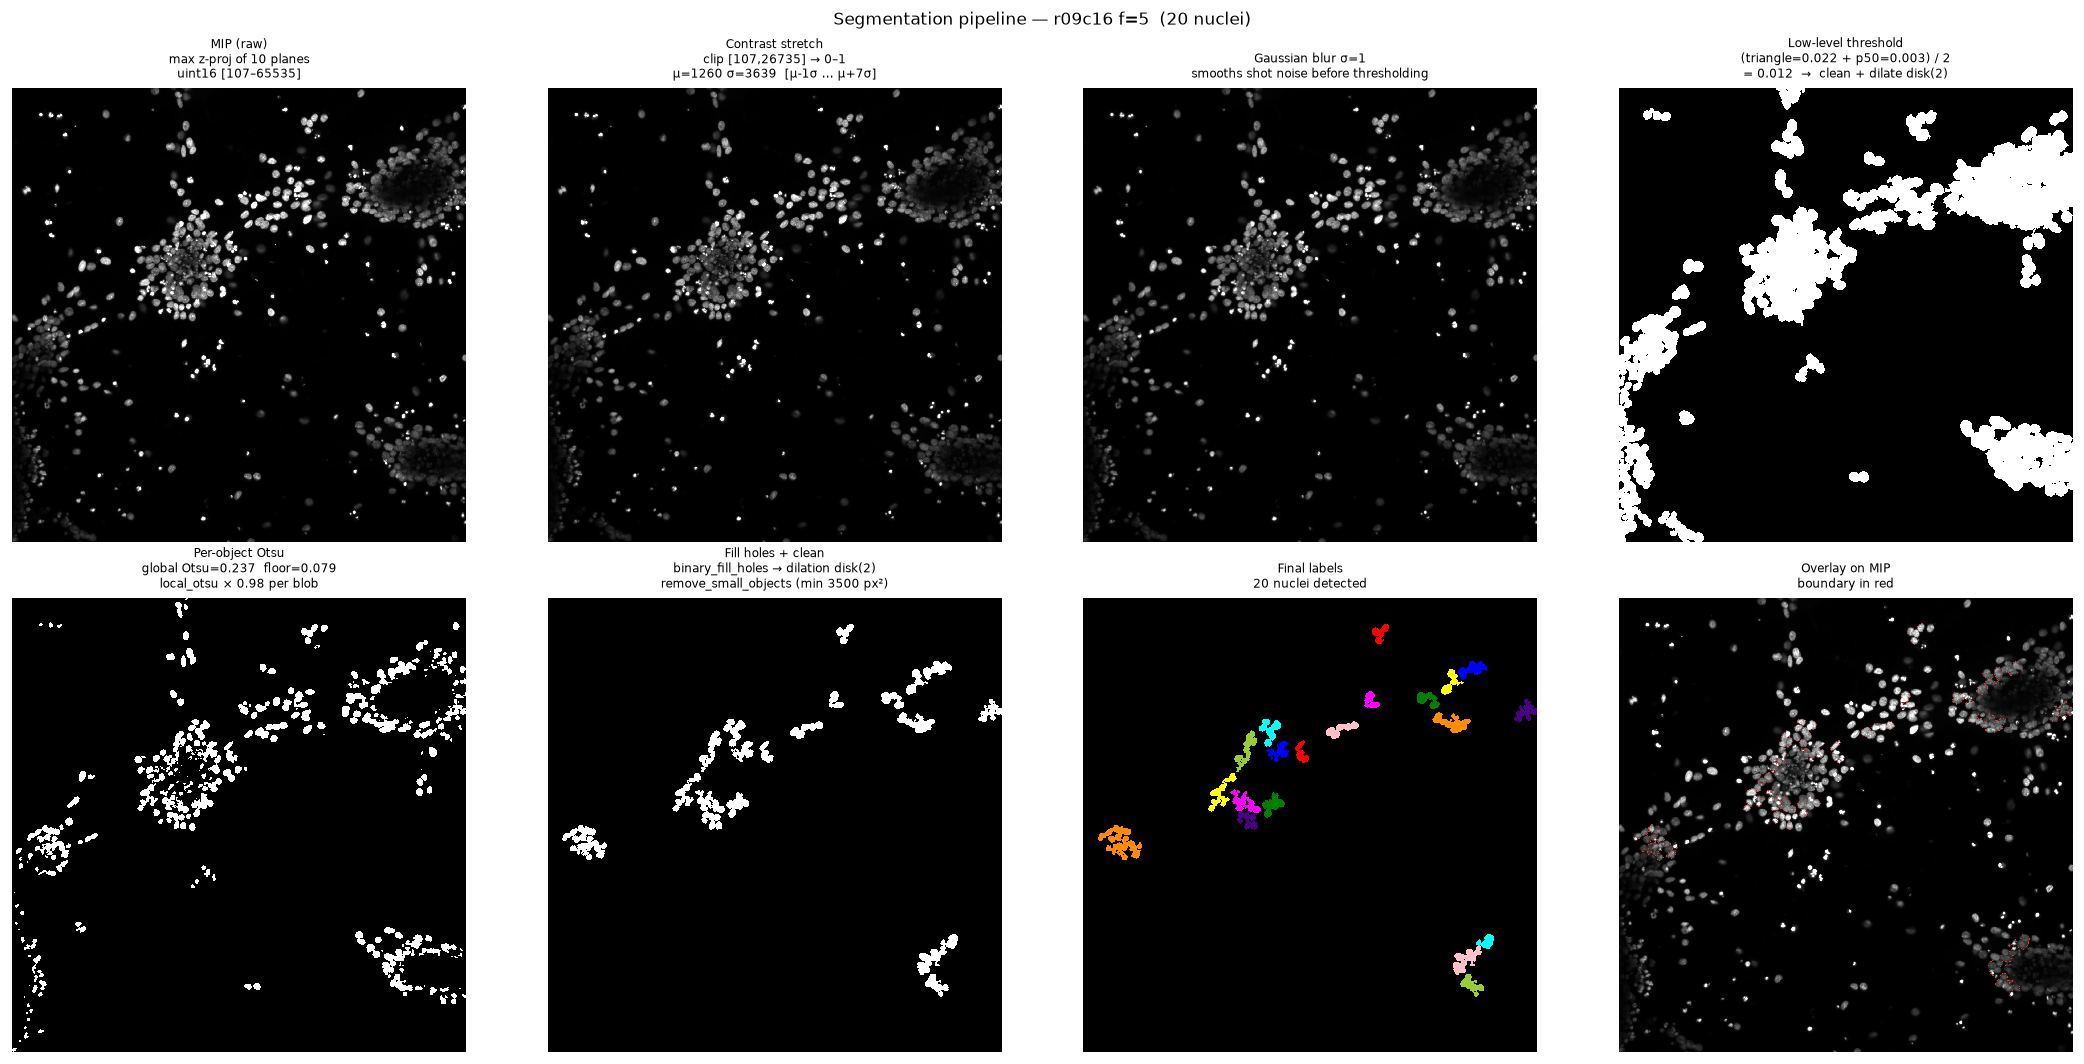

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle(f'Segmentation pipeline — r{WT_ROW:02d}c{WT_COL:02d} f={WT_FRAME}  '
             f'({steps["nuc_seg"].max()} nuclei)', fontsize=10)

panels = [
    ('MIP (raw)', steps['mip'], 'gray',
     f'max z-proj of {N_PLANES} planes\nuint16 [{steps["mip"].min():.0f}–{steps["mip"].max():.0f}]'),
    ('Contrast stretch', steps['image_norm'], 'gray',
     f'clip [{steps["stretch_min"]:.0f},{steps["stretch_max"]:.0f}] → 0–1\n'
     f'µ={steps["m"]:.0f} σ={steps["s"]:.0f}  [µ-1σ … µ+7σ]'),
    ('Gaussian blur σ=1', steps['blurred'], 'gray',
     'smooths shot noise before thresholding'),
    ('Low-level threshold', steps['img_low_dilated'].astype(float), 'gray',
     f'(triangle={steps["triangle_cutoff"]:.3f} + p50={steps["median_cutoff"]:.3f}) / 2\n'
     f'= {steps["th_low"]:.3f}  →  clean + dilate disk(2)'),
    ('Per-object Otsu', steps['img_high'].astype(float), 'gray',
     f'global Otsu={steps["global_otsu"]:.3f}  floor={steps["otsu_floor"]:.3f}\n'
     f'local_otsu × 0.98 per blob'),
    ('Fill holes + clean', steps['filled_clean'].astype(float), 'gray',
     f'binary_fill_holes → dilation disk(2)\n'
     f'remove_small_objects (min {MIN_AREA} px²)'),
    ('Final labels', None, None,
     f'{steps["nuc_seg"].max()} nuclei detected'),
    ('Overlay on MIP', None, None, 'boundary in red'),
]

vmin_raw = np.percentile(steps['mip'], 1)
vmax_raw = np.percentile(steps['mip'], 99.5)

for ax, (title, img, cmap, note) in zip(axes.flat, panels):
    if title == 'Final labels':
        ax.imshow(label2rgb(steps['nuc_seg'], bg_label=0), interpolation='none')
    elif title == 'Overlay on MIP':
        boundary = find_boundaries(steps['nuc_seg'], mode='outer')
        ax.imshow(steps['mip'], cmap='gray', vmin=vmin_raw, vmax=vmax_raw, interpolation='none')
        red = np.zeros((*steps['mip'].shape, 4), dtype=np.float32)
        red[boundary] = [1.0, 0.2, 0.2, 0.9]
        ax.imshow(red, interpolation='none')
    elif cmap == 'gray' and img.dtype == float and img.max() <= 1.0:
        ax.imshow(img, cmap=cmap, vmin=0, vmax=1, interpolation='none')
    elif title == 'MIP (raw)':
        ax.imshow(img, cmap=cmap, vmin=vmin_raw, vmax=vmax_raw, interpolation='none')
    else:
        ax.imshow(img, cmap=cmap, interpolation='none')
    ax.set_title(f'{title}\n{note}', fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUT_DIR / 'segmentation_pipeline_full_field.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Nucleus-level crops — each segmentation step zoomed in

Pick 4 nuclei from the walkthrough site and show every pipeline stage cropped around each one.  
This reveals the per-object Otsu refinement effect (step 2) that sharpens boundaries.

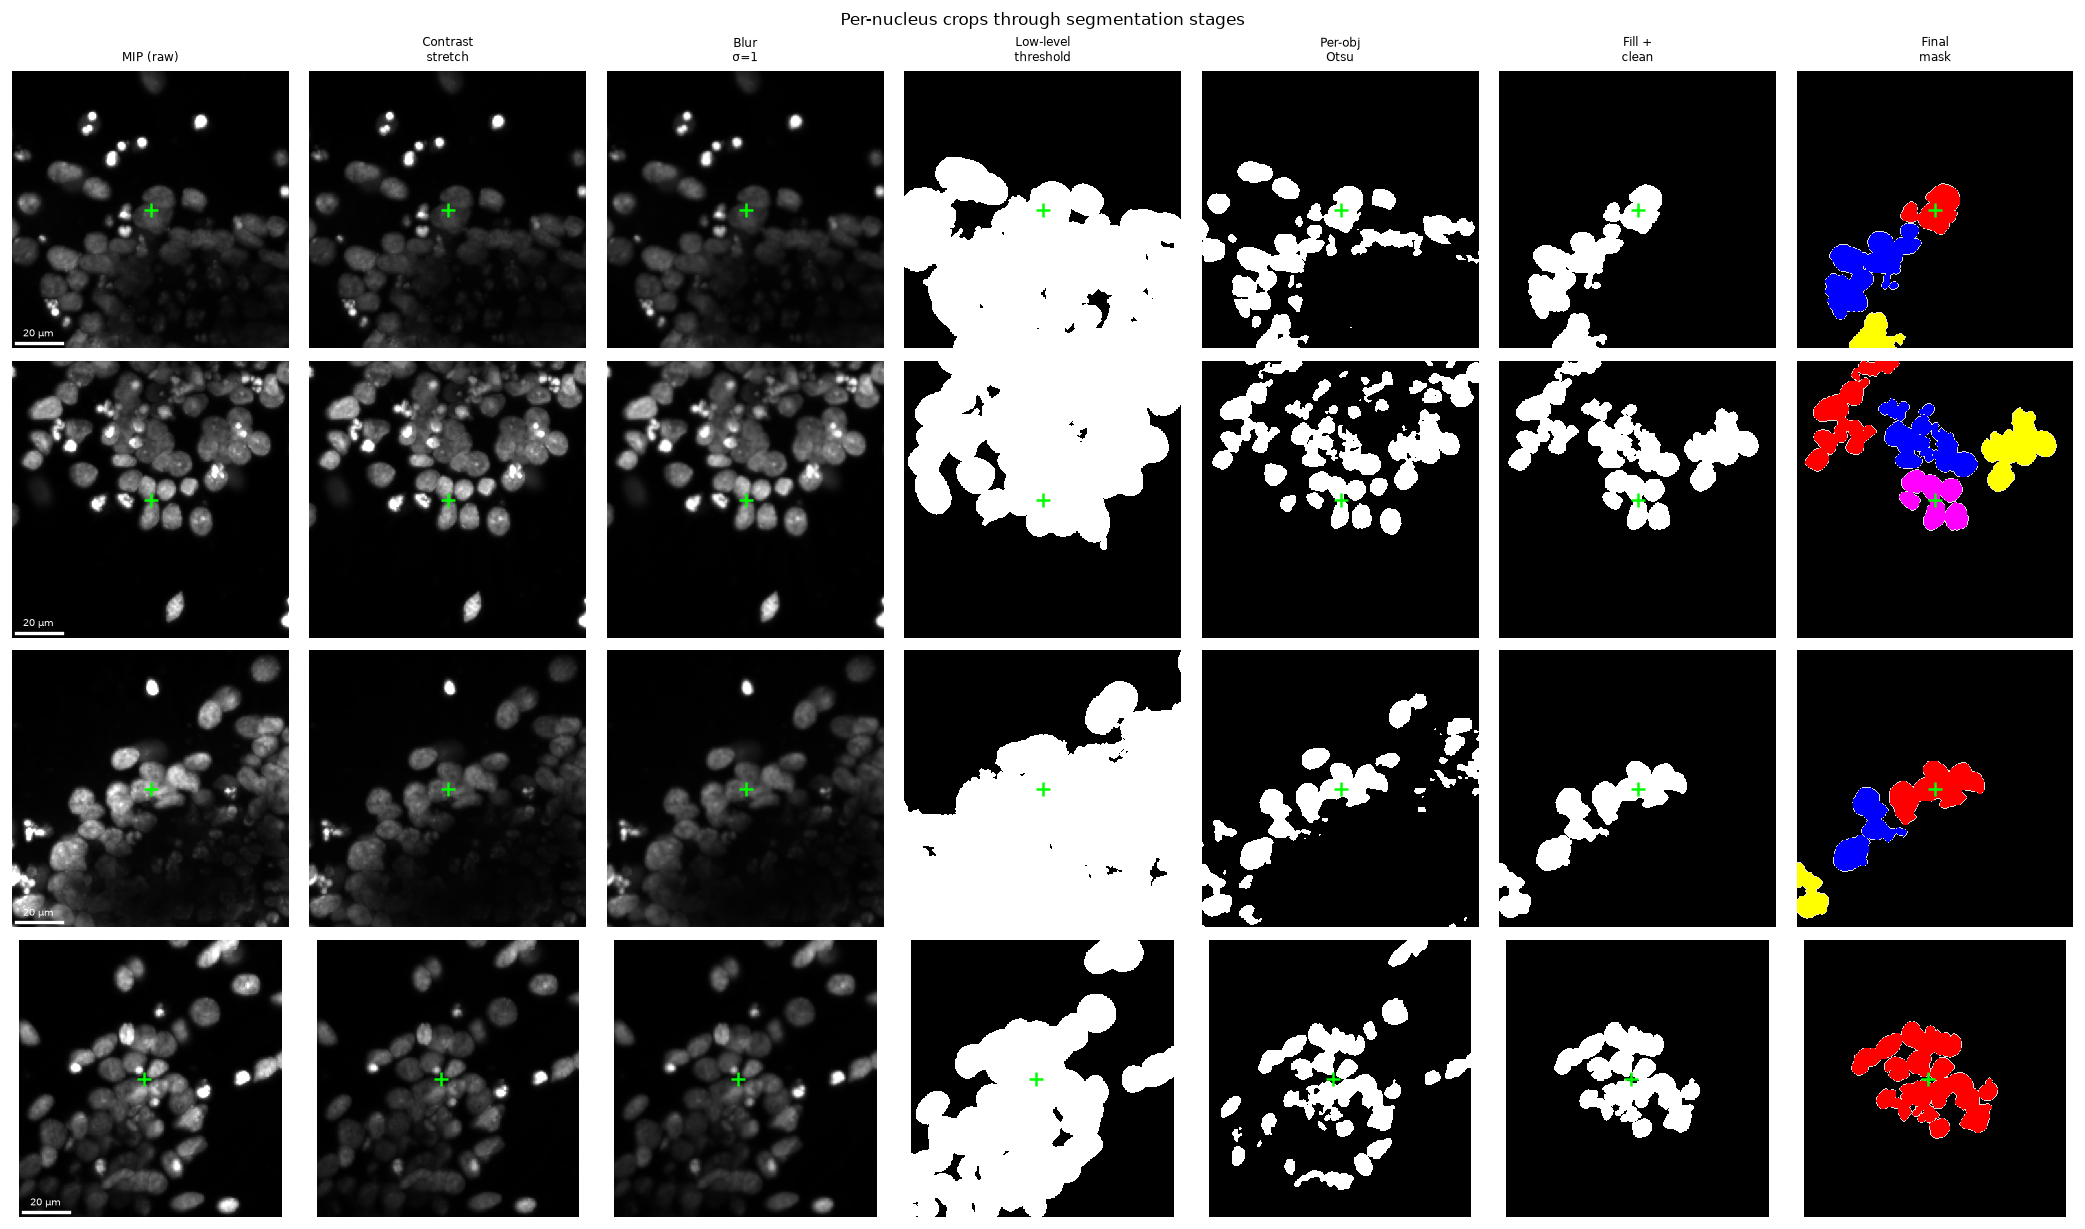

In [7]:
# Get nuclei from this site in the parquet
site_df = df[(df.Row == WT_ROW) & (df.Column == WT_COL) & (df.Frame == WT_FRAME)].copy()
# Sort by area descending to pick a range; take 4 spread across the size distribution
site_df = site_df.sort_values('area').reset_index(drop=True)
pick_idx = np.linspace(0, len(site_df)-1, min(4, len(site_df)), dtype=int)
picked = site_df.iloc[pick_idx]

CROP_R = int(60 / PX_UM)   # 60 µm radius crop window

stage_names = ['MIP (raw)', 'Contrast\nstretch', 'Blur\nσ=1',
               'Low-level\nthreshold', 'Per-obj\nOtsu', 'Fill +\nclean', 'Final\nmask']
stage_imgs  = [steps['mip'], steps['image_norm'], steps['blurred'],
               steps['img_low_dilated'], steps['img_high'],
               steps['filled_clean'], steps['nuc_seg']]
stage_cmaps = ['gray', 'gray', 'gray', 'gray', 'gray', 'gray', 'nipy_spectral']

n_stages = len(stage_names)
n_nuclei = len(picked)

fig, axes = plt.subplots(n_nuclei, n_stages, figsize=(n_stages * 2.5, n_nuclei * 2.6))
if n_nuclei == 1:
    axes = axes[np.newaxis, :]
fig.suptitle('Per-nucleus crops through segmentation stages', fontsize=10)

H, W = steps['mip'].shape
for row_i, (_, nuc_row) in enumerate(picked.iterrows()):
    cy, cx = int(round(nuc_row['centroid-0'])), int(round(nuc_row['centroid-1']))
    y0, y1 = max(0, cy - CROP_R), min(H, cy + CROP_R)
    x0, x1 = max(0, cx - CROP_R), min(W, cx + CROP_R)
    area_label = f"nucleus {row_i+1}\n{nuc_row['area_um2']:.0f} µm²"

    for col_i, (sname, simg, scmap) in enumerate(zip(stage_names, stage_imgs, stage_cmaps)):
        ax = axes[row_i, col_i]
        crop = simg[y0:y1, x0:x1]

        if simg.dtype == bool:
            ax.imshow(crop.astype(float), cmap='gray', vmin=0, vmax=1, interpolation='none')
        elif simg is steps['mip']:
            v0, v1 = np.percentile(crop, [1, 99.5])
            ax.imshow(crop, cmap='gray', vmin=v0, vmax=v1, interpolation='none')
        elif simg is steps['nuc_seg']:
            ax.imshow(label2rgb(crop, bg_label=0), interpolation='none')
            # overlay boundary
            bd = find_boundaries(crop, mode='outer')
            ov = np.zeros((*crop.shape, 4), dtype=float)
            ov[bd] = [1, 1, 1, 0.9]
            ax.imshow(ov, interpolation='none')
        else:
            ax.imshow(crop, cmap=scmap, vmin=0, vmax=1, interpolation='none')

        # Mark centroid with a cross
        lcy, lcx = cy - y0, cx - x0
        ax.plot(lcx, lcy, '+', color='lime', ms=8, mew=1.5)

        # Scale bar on first column (20 µm)
        if col_i == 0:
            sb = int(20 / PX_UM)
            ax.plot([5, 5+sb], [crop.shape[0]-8, crop.shape[0]-8], 'w-', lw=2)
            ax.text(5+sb//2, crop.shape[0]-14, '20 µm', color='w',
                    ha='center', va='bottom', fontsize=6)
            ax.set_ylabel(area_label, fontsize=7, rotation=0, ha='right', va='center')

        if row_i == 0:
            ax.set_title(sname, fontsize=7)
        ax.axis('off')

plt.tight_layout()
plt.savefig(OUT_DIR / 'nucleus_crops_pipeline_stages.png', dpi=130, bbox_inches='tight')
plt.show()

## 6. What the per-object Otsu step actually does

The Step 2 local Otsu is the key innovation over a simple global threshold.  
Here we visualise, for one nucleus, how the local threshold differs from the global one.

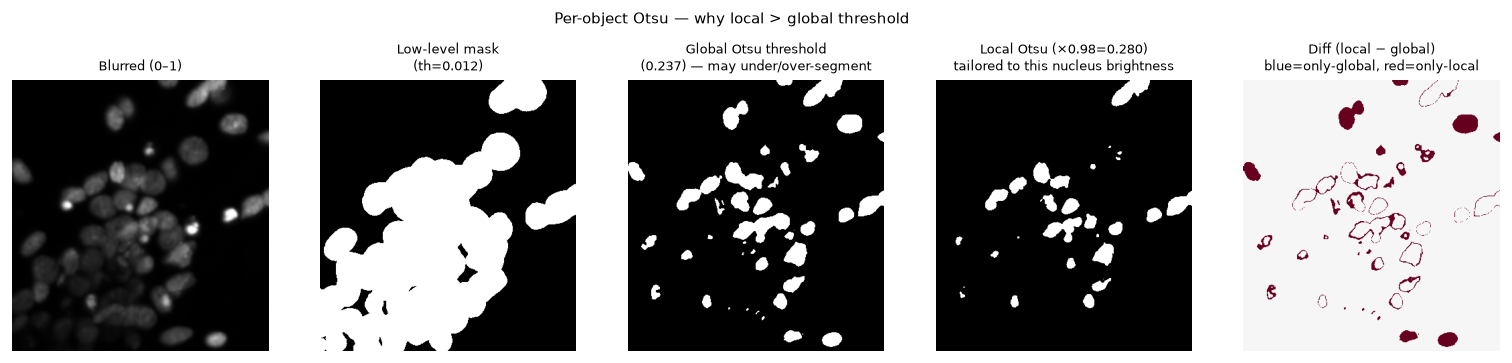

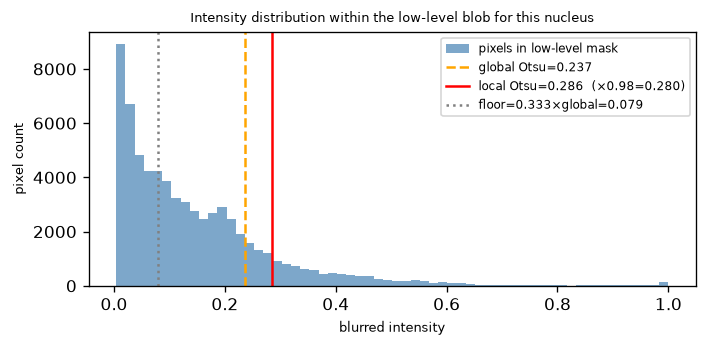

In [8]:
# Pick the largest nucleus in the site for clearest illustration
demo = site_df.sort_values('area').iloc[-1]
cy_d, cx_d = int(round(demo['centroid-0'])), int(round(demo['centroid-1']))
r = CROP_R
y0, y1 = max(0, cy_d - r), min(H, cy_d + r)
x0, x1 = max(0, cx_d - r), min(W, cx_d + r)

crop_blur = steps['blurred'][y0:y1, x0:x1]
crop_low  = (steps['img_low_dilated'])[y0:y1, x0:x1]

# Compute local Otsu for this object
lo = filters.threshold_otsu(steps['blurred'][steps['img_low_dilated']])
local_high = np.logical_and(steps['blurred'][y0:y1, x0:x1] > 0.98 * lo, crop_low)
global_high = steps['blurred'][y0:y1, x0:x1] > steps['global_otsu']

fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
fig.suptitle('Per-object Otsu — why local > global threshold', fontsize=9)

axes[0].imshow(crop_blur, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Blurred (0–1)')

axes[1].imshow(crop_low.astype(float), cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Low-level mask\n(th={steps["th_low"]:.3f})')

axes[2].imshow(global_high.astype(float), cmap='gray', vmin=0, vmax=1)
axes[2].set_title(f'Global Otsu threshold\n({steps["global_otsu"]:.3f}) — may under/over-segment')

axes[3].imshow(local_high.astype(float), cmap='gray', vmin=0, vmax=1)
axes[3].set_title(f'Local Otsu (×0.98={0.98*lo:.3f})\ntailored to this nucleus brightness')

# Difference
diff = local_high.astype(int) - global_high.astype(int)
axes[4].imshow(diff, cmap='RdBu', vmin=-1, vmax=1)
axes[4].set_title('Diff (local − global)\nblue=only-global, red=only-local')

for ax in axes:
    ax.axis('off')

# Pixel intensity histogram with both thresholds
fig2, ax = plt.subplots(figsize=(6, 3))
pixels = crop_blur[crop_low].ravel()
ax.hist(pixels, bins=60, color='steelblue', alpha=0.7, label='pixels in low-level mask')
ax.axvline(steps['global_otsu'], color='orange', linestyle='--',
           label=f'global Otsu={steps["global_otsu"]:.3f}')
ax.axvline(lo, color='red', linestyle='-',
           label=f'local Otsu={lo:.3f}  (×0.98={0.98*lo:.3f})')
ax.axvline(steps['otsu_floor'], color='gray', linestyle=':',
           label=f'floor=0.333×global={steps["otsu_floor"]:.3f}')
ax.set_xlabel('blurred intensity')
ax.set_ylabel('pixel count')
ax.set_title('Intensity distribution within the low-level blob for this nucleus')
ax.legend(fontsize=7)
plt.tight_layout()

plt.savefig(OUT_DIR / 'otsu_local_vs_global.png', dpi=130, bbox_inches='tight')
plt.show()

## 7. Multi-site QC grid — low / medium / high density

3 panels per site: DAPI MIP → labelled mask → boundary overlay.  
Shows how the algorithm behaves across different crowding conditions.

/var/folders/h_/dkrbbbb155n1ywvgwthdcyyr0000gs/T/ipykernel_37921/1958613307.py:17: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  img_low_clean        = morphology.remove_small_objects(img_low.astype(bool), min_size=MIN_AREA)
/var/folders/h_/dkrbbbb155n1ywvgwthdcyyr0000gs/T/ipykernel_37921/1958613307.py:36: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous

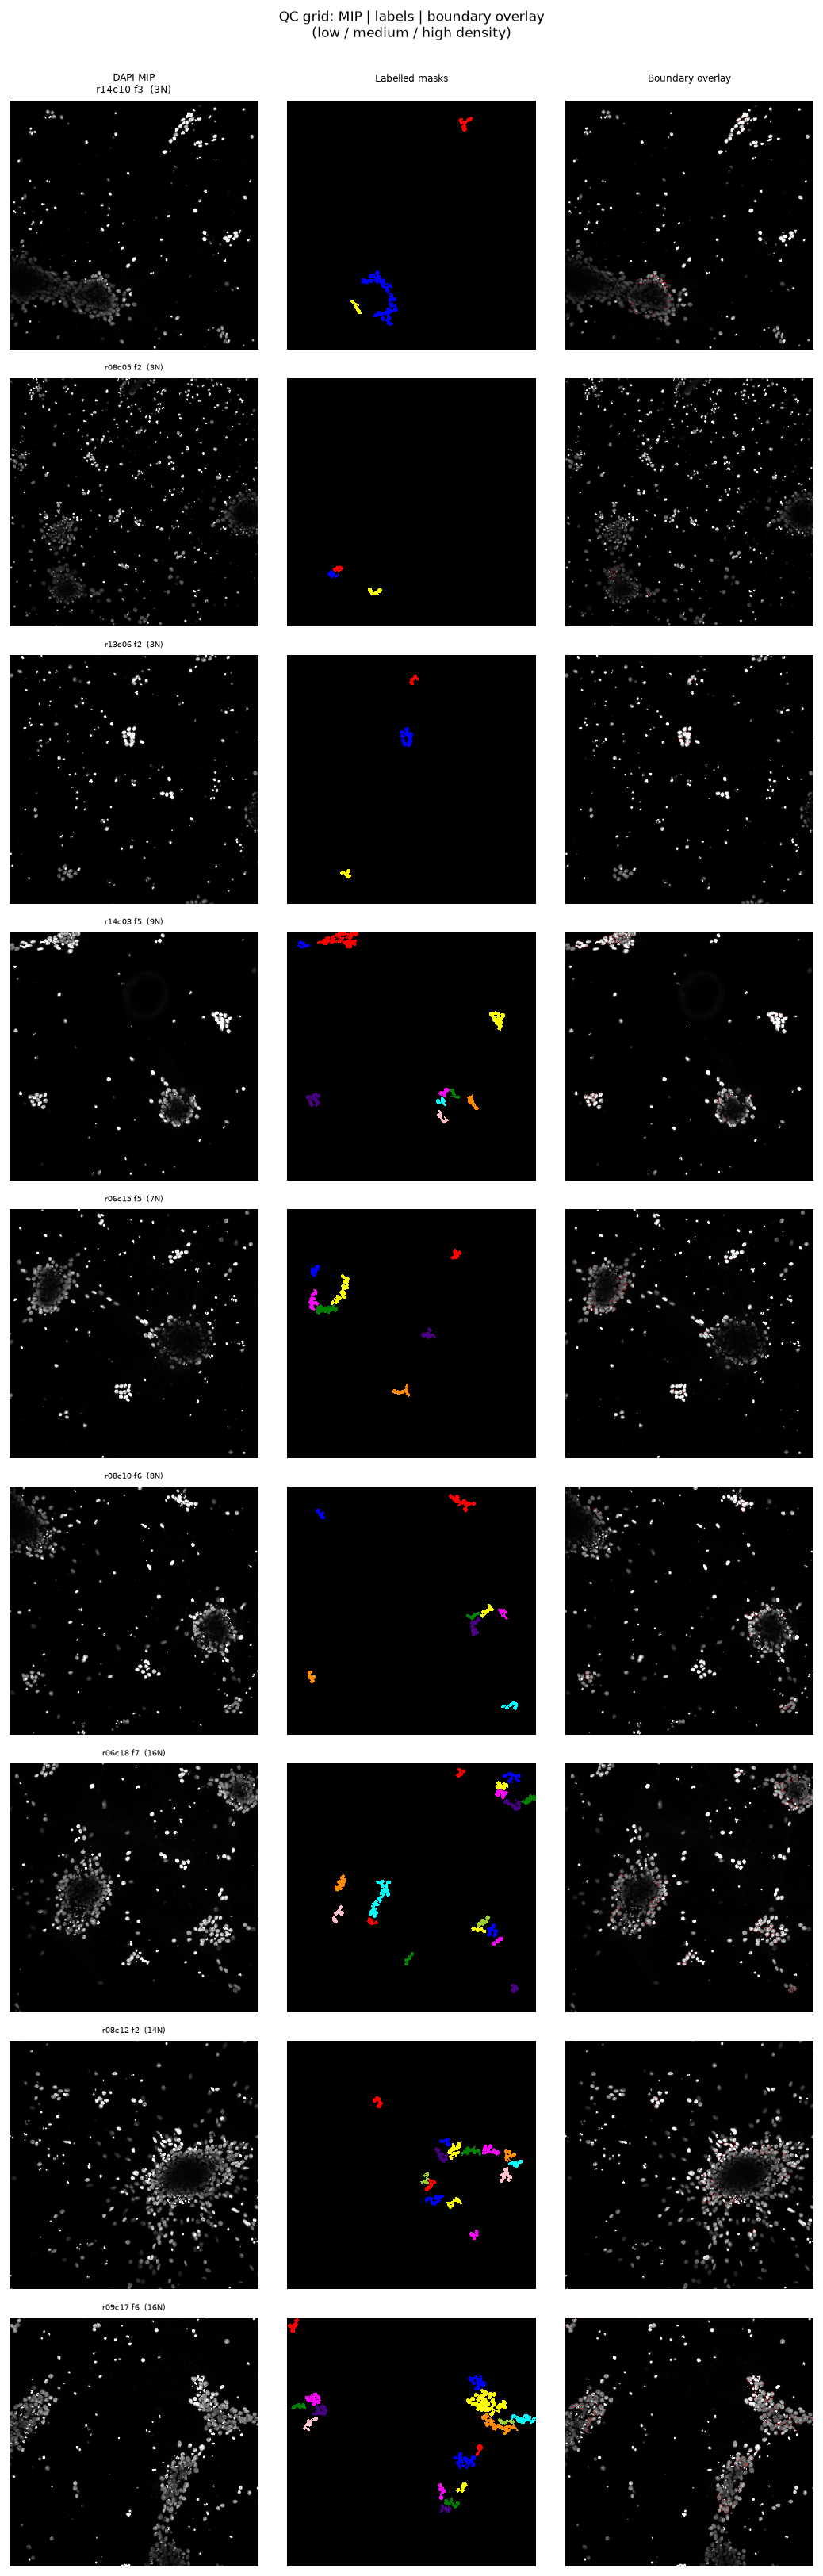

In [9]:
def load_and_segment_site(row, col, frame):
    paths = get_plane_paths(row, col, frame)
    raw_planes = [tifffile.imread(p) for p in paths if p.exists()]
    if not raw_planes:
        return None, None
    mip_img = np.max(np.stack(raw_planes), axis=0)
    seg_img  = segment_stepwise(mip_img)['nuc_seg']
    return mip_img, seg_img

def show_site_3panel(ax_mip, ax_mask, ax_bnd, row, col, frame, n_expected):
    mip_img, seg_img = load_and_segment_site(row, col, frame)
    if mip_img is None:
        for ax in (ax_mip, ax_mask, ax_bnd):
            ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
        return
    n_found = seg_img.max()
    title = f'r{row:02d}c{col:02d} f{frame}  ({n_found}N)'

    v0, v1 = np.percentile(mip_img, [1, 99.5])
    ax_mip.imshow(mip_img, cmap='gray', vmin=v0, vmax=v1, interpolation='none')
    ax_mip.set_title(title, fontsize=6)
    ax_mip.axis('off')

    ax_mask.imshow(label2rgb(seg_img, bg_label=0), interpolation='none')
    ax_mask.axis('off')

    bd = find_boundaries(seg_img, mode='outer')
    ax_bnd.imshow(mip_img, cmap='gray', vmin=v0, vmax=v1, interpolation='none')
    red = np.zeros((*mip_img.shape, 4), dtype=np.float32)
    red[bd] = [1.0, 0.15, 0.15, 0.9]
    ax_bnd.imshow(red, interpolation='none')
    ax_bnd.axis('off')

sc = site_counts.copy()
low_s  = sc[sc['n'] <= 3].sample(3, random_state=7)[['Row','Column','Frame','n']].values.tolist()
mid_s  = sc[sc['n'].between(6, 9)].sample(3, random_state=7)[['Row','Column','Frame','n']].values.tolist()
high_s = sc[sc['n'] >= 14].sample(3, random_state=7)[['Row','Column','Frame','n']].values.tolist()

groups = [('Low density (≤3)', low_s), ('Medium density (6–9)', mid_s), ('High density (≥14)', high_s)]

fig, axes = plt.subplots(9, 3, figsize=(9, 27))
fig.suptitle('QC grid: MIP | labels | boundary overlay\n(low / medium / high density)',
             fontsize=10, y=1.001)

row_offset = 0
for group_name, sites in groups:
    for site_i, (r, c, f, n) in enumerate(sites):
        ax_row = row_offset + site_i
        show_site_3panel(axes[ax_row, 0], axes[ax_row, 1], axes[ax_row, 2], r, c, f, n)
        if site_i == 0:
            axes[ax_row, 0].set_ylabel(group_name, fontsize=8, rotation=90, labelpad=40)
    row_offset += 3

# column headers
for ax, hdr in zip(axes[0], ['DAPI MIP', 'Labelled masks', 'Boundary overlay']):
    ax.set_title(f'{hdr}\n' + ax.get_title(), fontsize=7)

plt.tight_layout()
plt.savefig(OUT_DIR / 'qc_grid_density_tiers.png', dpi=130, bbox_inches='tight')
plt.show()

## 8. MIN_AREA diagnostic — why isolated neurons are missed

Looking at the pipeline figure, many clearly visible nuclei in the MIP are **not detected**. Only nuclei in dense clusters are labelled. This is a direct consequence of `MIN_AREA = 3500 px²` applied to the **low-level threshold binary mask**.

**How clustered vs isolated nuclei are treated differently:**

| Cell type | Low-level blob size | Survives `remove_small_objects`? | Result |
|-----------|--------------------|---------------------------------|--------|
| Cluster of 3–5 nuclei | 6000–20000 px² | ✅ yes → per-object Otsu splits them | **Detected** |
| Isolated single neuron | ~300–1500 px² | ❌ no — below 3500 px² | **Missed** |

**Why MIN_AREA=3500 is wrong for this pixel size:**

At Panel_1 (0.094 µm/px): `3500 px² = 31 µm²` — correctly removes sub-nuclear debris  
At HS-array (0.297 µm/px): `3500 px² = 308 µm²` — removes all nuclei smaller than ~20 µm diameter  

A typical iNeuron nucleus (10–15 µm diameter) is **50–177 µm² = 568–2019 px²** at this pixel size — entirely below the floor.

Raw low-level blobs (no area filter): 400
  median area: 138 px²  =  12.1 µm²


/var/folders/h_/dkrbbbb155n1ywvgwthdcyyr0000gs/T/ipykernel_37921/3961944884.py:35: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  low_3500 = morphology.remove_small_objects(raw_low, min_size=3500)
/var/folders/h_/dkrbbbb155n1ywvgwthdcyyr0000gs/T/ipykernel_37921/3961944884.py:36: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed small

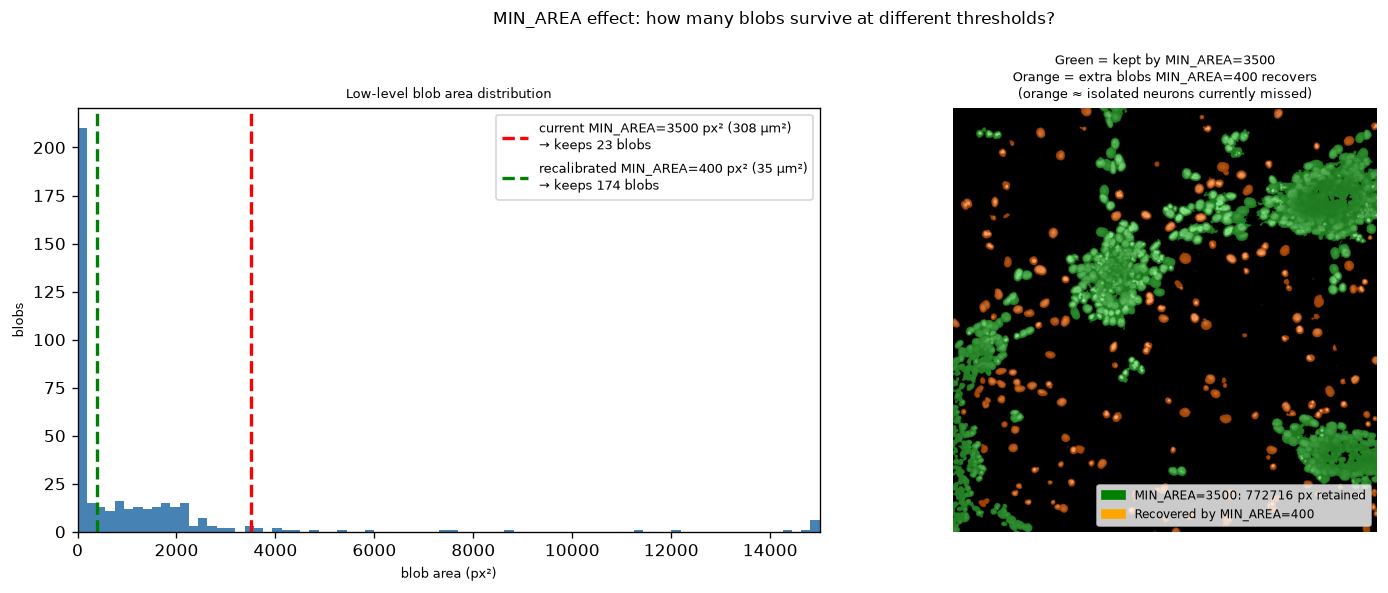


Nuclei visible in MIP but missed by current MIN_AREA=3500:
  Blobs ≥400 px²:  174
  Blobs ≥3500 px²: 23
  Missed:          151  (87% of detectable cells)

Recommendation: set MIN_AREA = 350–500 px² (30–44 µm²) in 1_nucleus_segmentation.py
  → equivalent to the original 31 µm² floor at Panel_1 pixel size


In [10]:
# Show the effect concretely: how many low-level blobs are lost at each MIN_AREA value
from skimage.measure import label as sk_label

m_demo, s_demo = norm.fit(mip.flatten())
stretch_min_d = max(m_demo - 1*s_demo, mip.min())
stretch_max_d = min(m_demo + 7*s_demo, mip.max())
norm_d = (np.clip(mip, stretch_min_d, stretch_max_d) - stretch_min_d) / (stretch_max_d - stretch_min_d)
blur_d = filters.gaussian(norm_d, sigma=1)
th_d   = (filters.threshold_triangle(blur_d) + np.percentile(blur_d, 50)) / 2
raw_low = blur_d > th_d   # binary before any filtering

blobs_all = regionprops_table(sk_label(raw_low), properties=['label', 'area'])
blob_areas = pd.Series(blobs_all['area'])

print(f"Raw low-level blobs (no area filter): {len(blob_areas)}")
print(f"  median area: {blob_areas.median():.0f} px²  =  {blob_areas.median()*PX_UM**2:.1f} µm²")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('MIN_AREA effect: how many blobs survive at different thresholds?', fontsize=10)

ax = axes[0]
ax.hist(blob_areas.clip(0, 15000), bins=80, color='steelblue', edgecolor='none')
for ma, color, label in [
    (3500, 'red',    f'current MIN_AREA=3500 px² (308 µm²)\n→ keeps {(blob_areas>=3500).sum()} blobs'),
    (400,  'green',  f'recalibrated MIN_AREA=400 px² (35 µm²)\n→ keeps {(blob_areas>=400).sum()} blobs'),
]:
    ax.axvline(ma, color=color, ls='--', lw=2, label=label)
ax.set_xlabel('blob area (px²)'); ax.set_ylabel('blobs'); ax.set_title('Low-level blob area distribution')
ax.legend(fontsize=8); ax.set_xlim(0, 15000)

# Side-by-side: current MIN_AREA=3500 vs proposed MIN_AREA=400
ax = axes[1]
from skimage.color import label2rgb as l2rgb

low_3500 = morphology.remove_small_objects(raw_low, min_size=3500)
low_400  = morphology.remove_small_objects(raw_low, min_size=400)
# composite: red=only in 400, green=in both
comp = np.zeros((*raw_low.shape, 3), dtype=np.float32)
comp[low_400 & ~low_3500] = [1.0, 0.4, 0.0]   # orange = extra blobs MIN_AREA=400 recovers
comp[low_3500]             = [0.2, 0.8, 0.2]   # green  = kept by both
ax.imshow(mip, cmap='gray', vmin=np.percentile(mip,1), vmax=np.percentile(mip,99.5))
ax.imshow(comp, alpha=0.6)
ax.set_title('Green = kept by MIN_AREA=3500\nOrange = extra blobs MIN_AREA=400 recovers\n(orange ≈ isolated neurons currently missed)')
ax.axis('off')
patch_g = mpatches.Patch(color='green',  label=f'MIN_AREA=3500: {low_3500.sum()//1} px retained')
patch_o = mpatches.Patch(color='orange', label=f'Recovered by MIN_AREA=400')
ax.legend(handles=[patch_g, patch_o], fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig(OUT_DIR / 'min_area_diagnostic.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"\nNuclei visible in MIP but missed by current MIN_AREA=3500:")
print(f"  Blobs ≥400 px²:  {(blob_areas>=400).sum()}")
print(f"  Blobs ≥3500 px²: {(blob_areas>=3500).sum()}")
print(f"  Missed:          {(blob_areas>=400).sum() - (blob_areas>=3500).sum()}"
      f"  ({100*(1-(blob_areas>=3500).sum()/(blob_areas>=400).sum()):.0f}% of detectable cells)")
print(f"\nRecommendation: set MIN_AREA = 350–500 px² (30–44 µm²) in 1_nucleus_segmentation.py"
      f"\n  → equivalent to the original 31 µm² floor at Panel_1 pixel size")

QC area range: 20–200 µm² = 227–2272 px²  (at 0.2967 µm/px)
MIN_AREA used in segmentation: 3500 px² = 308 µm²
Nuclei above 200 µm² (potential doublets/debris): 10198 / 10198


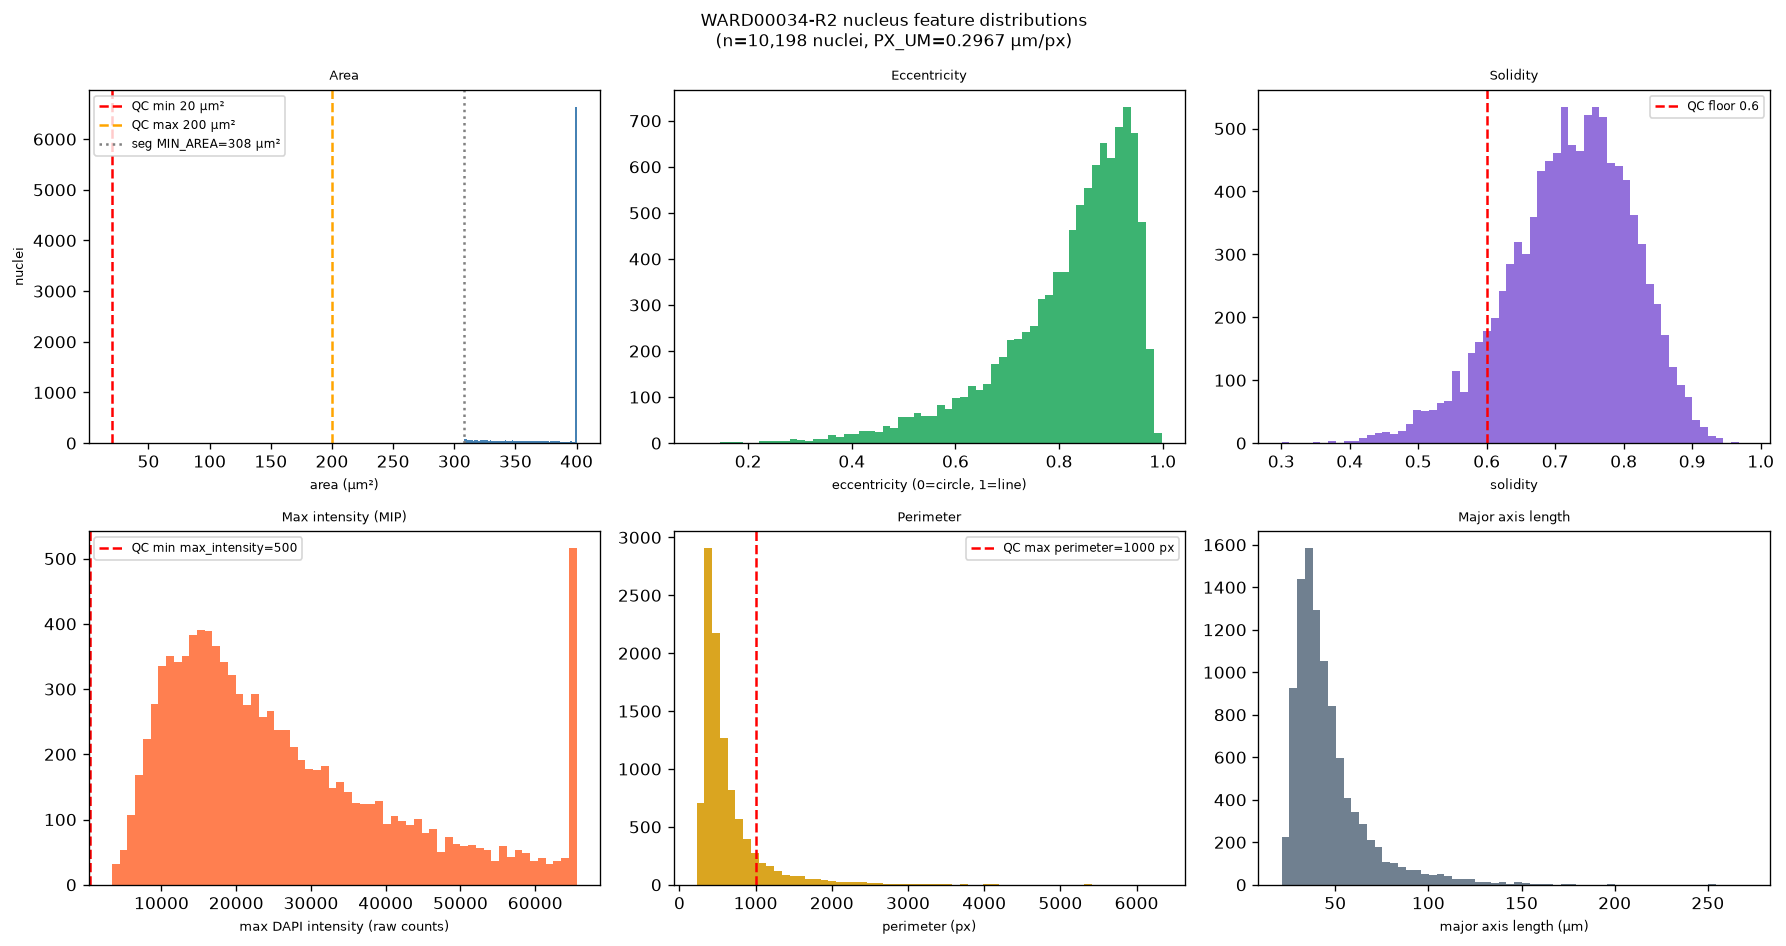


--- QC pass rates ---
Area 20–200 µm²:       0.0%  pass
Max intensity > 500:   100.0%  pass
Perimeter < 1000 px:   88.4%  pass
Solidity >= 0.6:       90.1%  pass


In [11]:
QC_AREA_MIN_UM2 = 20
QC_AREA_MAX_UM2 = 200
QC_AREA_MIN_PX2 = QC_AREA_MIN_UM2 / PX_UM**2
QC_AREA_MAX_PX2 = QC_AREA_MAX_UM2 / PX_UM**2

print(f'QC area range: {QC_AREA_MIN_UM2}–{QC_AREA_MAX_UM2} µm²'
      f' = {QC_AREA_MIN_PX2:.0f}–{QC_AREA_MAX_PX2:.0f} px²  (at 0.2967 µm/px)')
print(f'MIN_AREA used in segmentation: {MIN_AREA} px² = {MIN_AREA*PX_UM**2:.0f} µm²')
print(f'Nuclei above 200 µm² (potential doublets/debris): '
      f'{(df.area_um2 > QC_AREA_MAX_UM2).sum()} / {len(df)}')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('WARD00034-R2 nucleus feature distributions\n'
             f'(n={len(df):,} nuclei, PX_UM={PX_UM} µm/px)', fontsize=10)

# Area
ax = axes[0, 0]
ax.hist(df['area_um2'].clip(0, 400), bins=80, color='steelblue', edgecolor='none')
ax.axvline(QC_AREA_MIN_UM2, color='red',    ls='--', lw=1.5, label=f'QC min {QC_AREA_MIN_UM2} µm²')
ax.axvline(QC_AREA_MAX_UM2, color='orange', ls='--', lw=1.5, label=f'QC max {QC_AREA_MAX_UM2} µm²')
ax.axvline(MIN_AREA * PX_UM**2, color='gray', ls=':', lw=1.5, label=f'seg MIN_AREA={MIN_AREA*PX_UM**2:.0f} µm²')
ax.set_xlabel('area (µm²)'); ax.set_ylabel('nuclei'); ax.set_title('Area')
ax.legend(fontsize=7)

# Eccentricity
ax = axes[0, 1]
ax.hist(df['eccentricity'], bins=60, color='mediumseagreen', edgecolor='none')
ax.set_xlabel('eccentricity (0=circle, 1=line)'); ax.set_title('Eccentricity')

# Solidity
ax = axes[0, 2]
ax.hist(df['solidity'], bins=60, color='mediumpurple', edgecolor='none')
ax.axvline(0.6, color='red', ls='--', lw=1.5, label='QC floor 0.6')
ax.set_xlabel('solidity'); ax.set_title('Solidity'); ax.legend(fontsize=7)

# Max intensity
ax = axes[1, 0]
ax.hist(df['intensity_max'], bins=60, color='coral', edgecolor='none')
ax.axvline(500, color='red', ls='--', lw=1.5, label='QC min max_intensity=500')
ax.set_xlabel('max DAPI intensity (raw counts)'); ax.set_title('Max intensity (MIP)'); ax.legend(fontsize=7)

# Perimeter
ax = axes[1, 1]
ax.hist(df['perimeter'], bins=60, color='goldenrod', edgecolor='none')
ax.axvline(1000, color='red', ls='--', lw=1.5, label='QC max perimeter=1000 px')
ax.set_xlabel('perimeter (px)'); ax.set_title('Perimeter'); ax.legend(fontsize=7)

# Major axis length
ax = axes[1, 2]
ax.hist(df['axis_major_length'] * PX_UM, bins=60, color='slategray', edgecolor='none')
ax.set_xlabel('major axis length (µm)'); ax.set_title('Major axis length')

plt.tight_layout()
plt.savefig(OUT_DIR / 'feature_distributions_calibrated.png', dpi=130, bbox_inches='tight')
plt.show()

# Summary table
print('\n--- QC pass rates ---')
print(f'Area 20–200 µm²:       {((df.area_um2>=20)&(df.area_um2<=200)).mean()*100:.1f}%  pass')
print(f'Max intensity > 500:   {(df.intensity_max>500).mean()*100:.1f}%  pass')
print(f'Perimeter < 1000 px:   {(df.perimeter<1000).mean()*100:.1f}%  pass')
print(f'Solidity >= 0.6:       {(df.solidity>=0.6).mean()*100:.1f}%  pass')

## 9. Per-well nucleus count heatmap

Plate-level view of segmentation success. Sparse wells flag either sparse cell seeding or imaging artefacts.

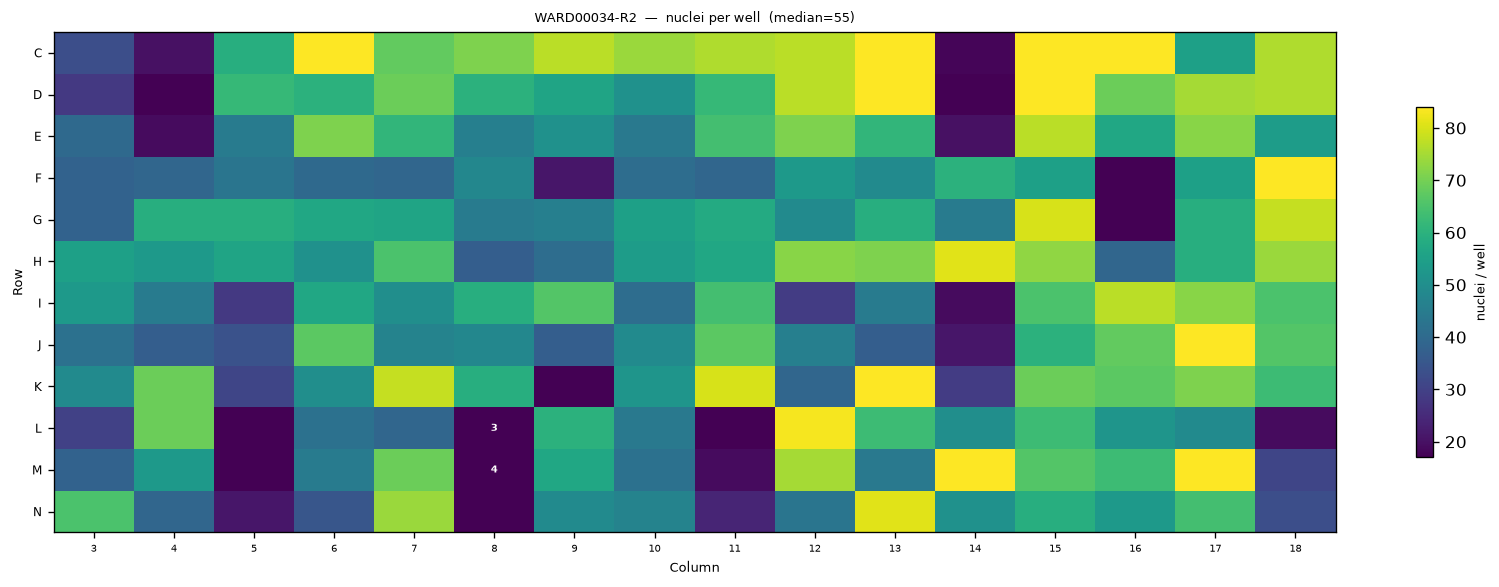

Lowest 5 wells:
 Row  Column  n_nuclei well
  12       8         3   L8
  13       8         4   M8
   7      16         9  G16
   4       4        10   D4
  14       8        10   N8


In [12]:
well_counts = df.groupby(['Row', 'Column']).size().reset_index(name='n_nuclei')

# Full 16×24 plate grid (Opera Phenix layout, rows 3–14, cols 3–26 for 192 wells)
rows_present = sorted(well_counts['Row'].unique())
cols_present = sorted(well_counts['Column'].unique())
grid = np.full((len(rows_present), len(cols_present)), np.nan)
row_idx = {r: i for i, r in enumerate(rows_present)}
col_idx = {c: i for i, c in enumerate(cols_present)}

for _, wr in well_counts.iterrows():
    grid[row_idx[wr.Row], col_idx[wr.Column]] = wr.n_nuclei

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(grid, cmap='viridis', aspect='auto',
               vmin=np.nanpercentile(grid, 5), vmax=np.nanpercentile(grid, 95))
plt.colorbar(im, ax=ax, label='nuclei / well', shrink=0.7)

ax.set_xticks(range(len(cols_present)))
ax.set_xticklabels([str(c) for c in cols_present], fontsize=6)
ax.set_yticks(range(len(rows_present)))
ax.set_yticklabels([chr(64+r) for r in rows_present], fontsize=7)
ax.set_xlabel('Column'); ax.set_ylabel('Row')
ax.set_title(f'WARD00034-R2  —  nuclei per well  (median={int(np.nanmedian(grid))})')

# Annotate sparse wells (≤5)
for _, wr in well_counts[well_counts.n_nuclei <= 5].iterrows():
    ax.text(col_idx[wr.Column], row_idx[wr.Row], f'{int(wr.n_nuclei)}',
            ha='center', va='center', fontsize=6, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / 'plate_heatmap_nuclei_per_well.png', dpi=130, bbox_inches='tight')
plt.show()

print('Lowest 5 wells:')
print(well_counts.nsmallest(5, 'n_nuclei').assign(
    well=lambda x: x.Row.apply(lambda r: chr(64+r)) + x.Column.astype(str)).to_string(index=False))

## 10. Summary & open issues

| Item | Value |
|------|-------|
| Pixel size | 0.2967 µm/px (from `index.xml`) |
| Z-planes | 10 × 1.997 µm ≈ 20 µm depth |
| Segmentation input | DAPI MIP (max over 10 z-planes) |
| Intensity input (Step 3) | Best-focus z-plane (max var-of-Laplacian per field) |
| Algorithm | Two-step: (triangle+p50)/2 low-level → per-object 0.98×local-Otsu high-level |
| Current MIN_AREA | 3500 px² = **308 µm²** at 0.2967 µm/px |
| Nuclei detected (WARD00034-R2) | 10,198 across 192 wells (median 55/well, 6/site) |

### ⚠️ Critical finding: MIN_AREA is miscalibrated for this pixel size

`MIN_AREA = 3500` was set for Panel_1 at **0.094 µm/px** where it equals **31 µm²** — a reasonable sub-nuclear debris floor.

At this dataset's **0.2967 µm/px**, `3500 px² = 308 µm²` — equivalent to a ~20 µm diameter nucleus. A typical iNeuron nucleus (10–15 µm diameter) is only **50–177 µm² = 568–2019 px²**. Any isolated neuron whose low-level blob is < 3500 px² is silently removed before reaching the Otsu refinement step.

**Consequence:** only nuclei in dense clusters (where merged blobs exceed 3500 px²) are detected. Isolated neurons — which may be enriched in particular perturbation conditions — are systematically excluded.

**Fix:** change `MIN_AREA = 3500` → `MIN_AREA = 400` (35 µm²) in `1_nucleus_segmentation.py`.  
This matches the original intent (remove sub-nuclear debris) without discarding real isolated cells.  
**This change will increase nucleus yield substantially — re-run QC on WARD00034-R2 after changing it.**

### Other open issues
2. **QC thresholds need recalibration:** `Nucleus_filters_testing.ipynb` thresholds assume 0.094 µm/px. Area 20–200 µm² = 227–2272 px² at 0.2967 µm/px.
3. **Well-edge ring artifact:** visible in edge frames (1,2,3,7,9 of the 9-field 3×3 grid). Algorithm correctly rejects it (hollow → fails per-object Otsu), but note the contrast-stretch distortion in those fields.
4. **Compartment masks (Step 3):** concentric-disk proxy under-sizes real nuclei and leaks neighbour nuclei. Upgrade: use Step-1 label image for nuclear/adjacent/cytoplasm masks.

### Reuse pointers
- `segment_stepwise()` → drop into any new site-level QC with intermediates
- `show_site_3panel()` → reuse for multi-plate comparison grids
- `min_area_diagnostic.png` → bring to lab meeting; use to justify MIN_AREA fix
- Feature distributions with correct PX_UM → copy to R QC script, replace `px_factor = 0.09419`